<a href="https://colab.research.google.com/github/waymaker55/ehijeleabhulimhen.github.io./blob/main/newcode2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/content/drive/MyDrive/Data_Mining/Tourism_Data_Combined_2010-2024.csv
Data Loaded. Shape: (180, 5)
            Arrivals    GDP    CPI  EUR_USD  EUR_GBP
Date                                                
2010-01-01    574830  43000   99.5     1.44     0.88
2010-02-01    543531  43000   99.6     1.36     0.87
2010-03-01    643989  43000  100.0     1.35     0.90
2010-04-01    845185  43500  100.2     1.33     0.87
2010-05-01   1011505  43500  100.1     1.24     0.85

--- Step 2: Generating EDA Plots ---


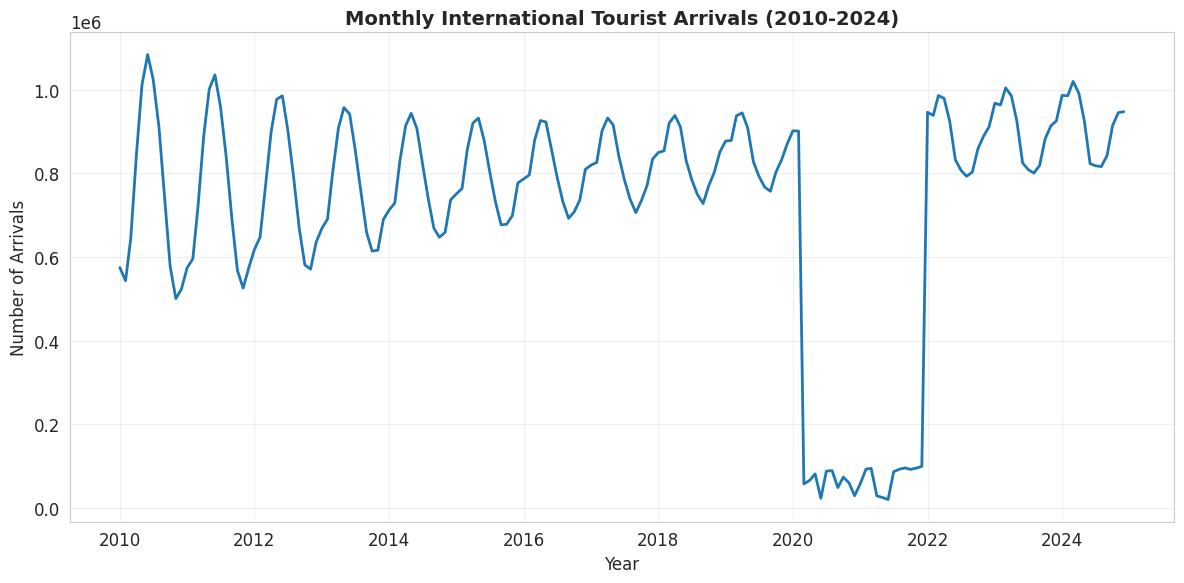

/tmp/ipython-input-723587008.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Month', y='Arrivals', data=df_eda, order=months_order, palette="Blues")


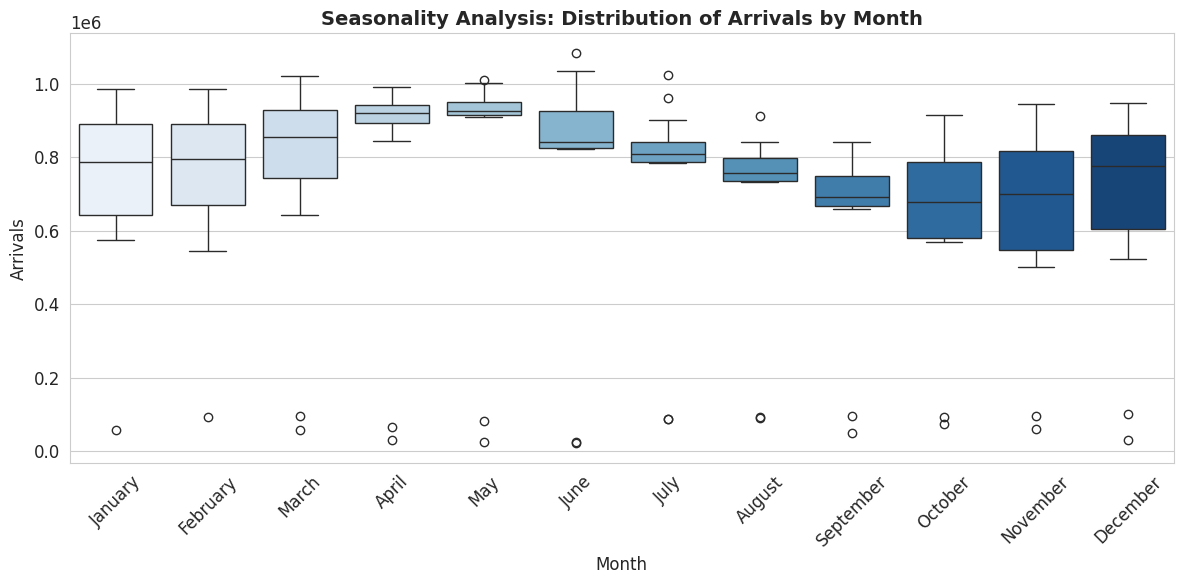

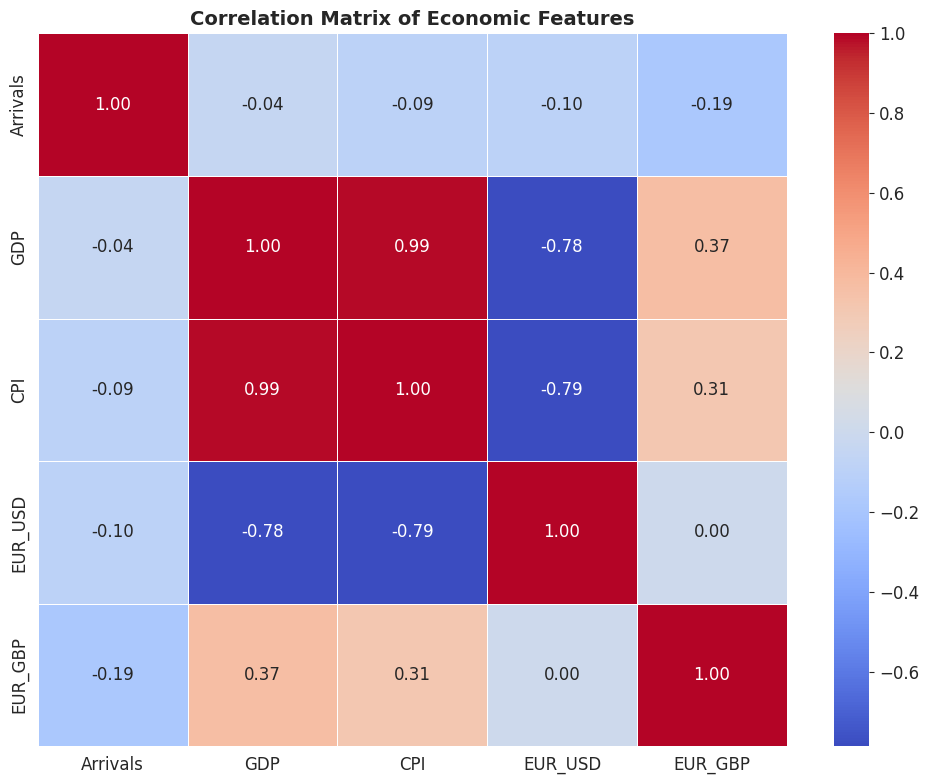


--- Step 3: Feature Engineering ---
Features Created: Lags 1, 2, 3, 12 + Month_Sin/Cos
Target Distribution:
Demand_Level
Low         42
Shoulder    42
High        42
Peak        42
Name: count, dtype: int64


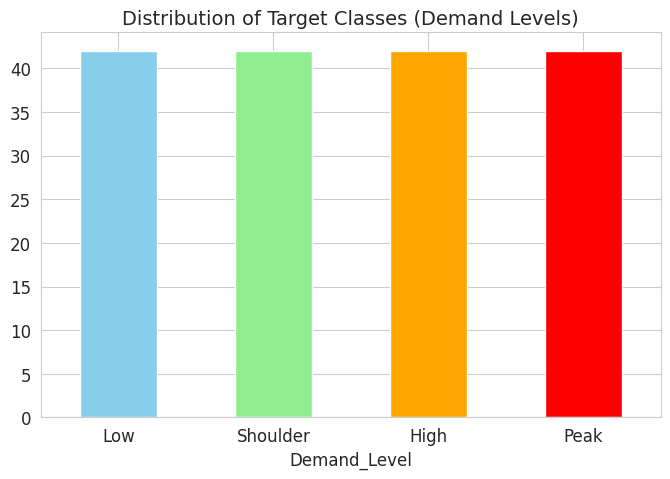


--- Step 4: Model Training & Evaluation ---
Training Samples: 134 | Test Samples: 34

--- Step 5: Results ---
SVC F1-Score (Scaled): 0.31
Random Forest F1-Score: 0.61
XGBoost F1-Score:       0.45


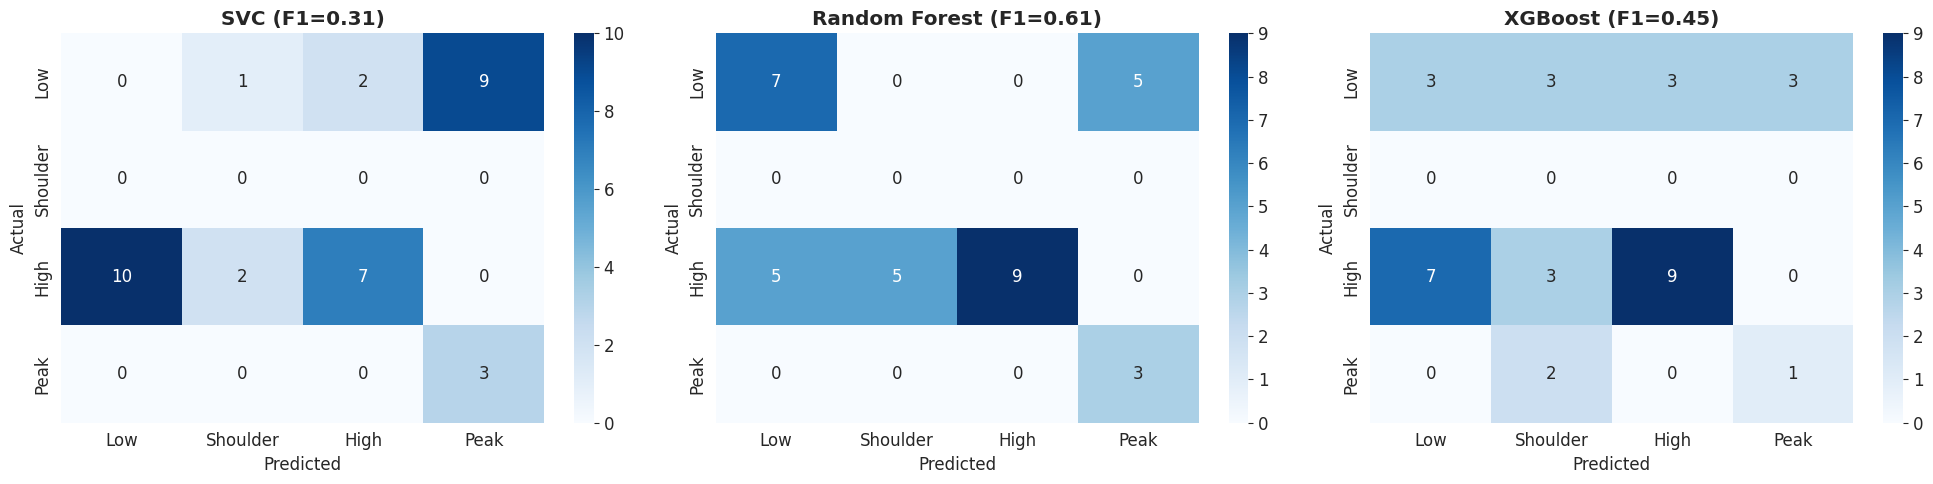

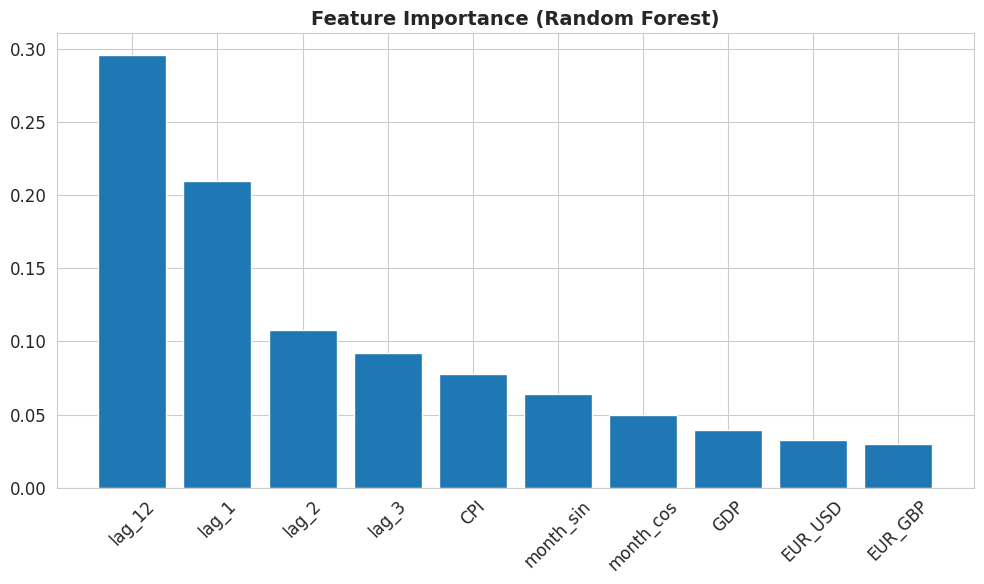


--- Step 6: Generating 2025 Forecast ---
Recursive Prediction Loop Starting...

=== 2025 FORECAST RESULTS ===
           Forecast_Label
Date                     
2025-01-01            Low
2025-02-01            Low
2025-03-01            Low
2025-04-01            Low
2025-05-01           Peak
2025-06-01           Peak
2025-07-01           Peak
2025-08-01           Peak
2025-09-01           Peak
2025-10-01            Low
2025-11-01            Low
2025-12-01            Low


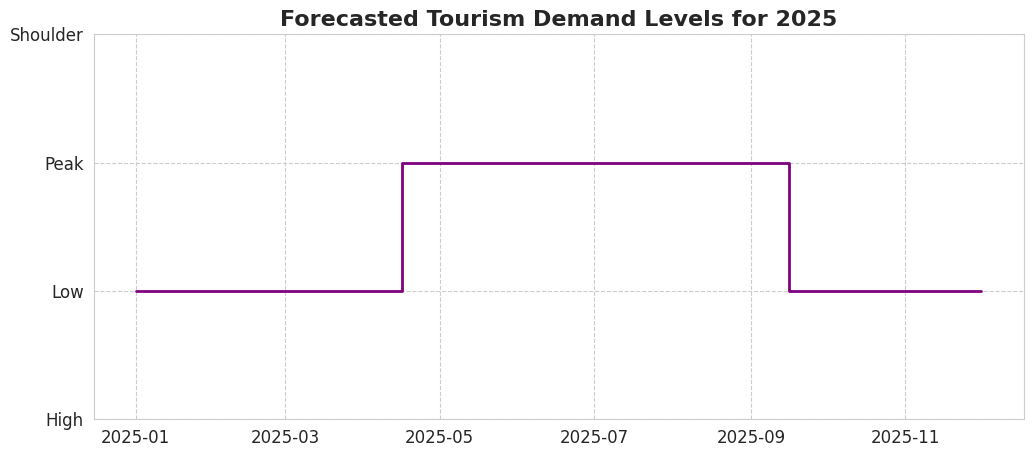

In [1]:
# ==============================================================================
# DISSERTATION CORRECTION: FINAL INTEGRATED NOTEBOOK
# ==============================================================================
# This script addresses all lecturer feedback:
# 1. DATA SOURCE: Uses real CSO data (Tourism_Data_Combined_2010-2024.csv).
# 2. FEATURES: Uses Lags 1, 2, 3, 12 and month_sin/cos seasonality.
# 3. LABELS: Uses 'Low', 'Shoulder', 'High', 'Peak'.
# 4. MODELING: Includes StandardScaler for SVC to fix low accuracy.
# 5. FORECAST: Generates 2025 predictions recursively.
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Set plot style for academic report
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

# ------------------------------------------------------------------------------
# 1. DATA LOADING & PREPARATION
# ------------------------------------------------------------------------------
print("/content/drive/MyDrive/Data_Mining/Tourism_Data_Combined_2010-2024.csv")
# Load the dataset
file_path = '/content/drive/MyDrive/Data_Mining/Tourism_Data_Combined_2010-2024.csv'
df = pd.read_csv(file_path)

# Clean and Convert Date
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

# Select relevant columns (Real Economic Indicators)
df = df[['Arrivals', 'GDP', 'CPI', 'EUR_USD', 'EUR_GBP']].copy()

# Handle any missing values (forward fill for time series stability)
df.ffill(inplace=True)

print("Data Loaded. Shape:", df.shape)
print(df.head())

# ------------------------------------------------------------------------------
# 2. EXPLORATORY DATA ANALYSIS (EDA) - Restored for Report
# ------------------------------------------------------------------------------
print("\n--- Step 2: Generating EDA Plots ---")

# Plot 1: Time Series of Arrivals
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Arrivals'], color='#1f77b4', linewidth=2)
plt.title('Monthly International Tourist Arrivals (2010-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Arrivals')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Seasonality Box Plot
df_eda = df.copy()
df_eda['Month'] = df_eda.index.month_name()
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
plt.figure(figsize=(12, 6))
sns.boxplot(x='Month', y='Arrivals', data=df_eda, order=months_order, palette="Blues")
plt.title('Seasonality Analysis: Distribution of Arrivals by Month', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot 3: Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Economic Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. FEATURE ENGINEERING (Strictly per Feedback)
# ------------------------------------------------------------------------------
print("\n--- Step 3: Feature Engineering ---")

# 1. Cyclical Time Features (Seasonality)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# 2. Lag Features (Exactly t-1, t-2, t-3, t-12 as promised in PDF)
for lag in [1, 2, 3, 12]:
    df[f'lag_{lag}'] = df['Arrivals'].shift(lag)

# Drop rows with NaN values created by lags (first 12 months)
df.dropna(inplace=True)

# 3. Target Labeling (Using 'Low', 'Shoulder', 'High', 'Peak')
# Using qcut for balanced classes as per methodology
labels = ['Low', 'Shoulder', 'High', 'Peak']
df['Demand_Level'] = pd.qcut(df['Arrivals'], q=4, labels=labels)

print("Features Created: Lags 1, 2, 3, 12 + Month_Sin/Cos")
print("Target Distribution:")
print(df['Demand_Level'].value_counts())

# Plot 4: Target Distribution
plt.figure(figsize=(8, 5))
df['Demand_Level'].value_counts().reindex(labels).plot(kind='bar', color=['skyblue', 'lightgreen', 'orange', 'red'])
plt.title('Distribution of Target Classes (Demand Levels)', fontsize=14)
plt.xticks(rotation=0)
plt.show()

# ------------------------------------------------------------------------------
# 4. MODEL TRAINING
# ------------------------------------------------------------------------------
print("\n--- Step 4: Model Training & Evaluation ---")

# Split Data (Chronological Split for Time Series)
X = df.drop(['Arrivals', 'Demand_Level'], axis=1)
y = df['Demand_Level']

# Encode Labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)
# Map back later: le.inverse_transform()

# 80-20 Time Series Split
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y_encoded[:split_idx], y_encoded[split_idx:]

print(f"Training Samples: {len(X_train)} | Test Samples: {len(X_test)}")

# --- Model 1: SVC with Scaling (The Fix) ---
# Pipeline ensures scaling happens inside CV to prevent leakage
svc_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', random_state=42))
])
# Simple Grid Search
svc_params = {'svc__C': [0.1, 1, 10, 100], 'svc__gamma': ['scale', 'auto']}
svc_grid = GridSearchCV(svc_pipe, svc_params, cv=3, scoring='f1_weighted')
svc_grid.fit(X_train, y_train)
y_pred_svc = svc_grid.predict(X_test)

# --- Model 2: Random Forest ---
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# --- Model 3: XGBoost ---
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

# ------------------------------------------------------------------------------
# 5. EVALUATION RESULTS & PLOTS
# ------------------------------------------------------------------------------
print("\n--- Step 5: Results ---")

def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

# F1 Scores
f1_svc = f1_score(y_test, y_pred_svc, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')
f1_xgb = f1_score(y_test, y_pred_xgb, average='weighted')

print(f"SVC F1-Score (Scaled): {f1_svc:.2f}")
print(f"Random Forest F1-Score: {f1_rf:.2f}")
print(f"XGBoost F1-Score:       {f1_xgb:.2f}")

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plot_confusion_matrix(y_test, y_pred_svc, f"SVC (F1={f1_svc:.2f})", axes[0])
plot_confusion_matrix(y_test, y_pred_rf, f"Random Forest (F1={f1_rf:.2f})", axes[1])
plot_confusion_matrix(y_test, y_pred_xgb, f"XGBoost (F1={f1_xgb:.2f})", axes[2])
plt.tight_layout()
plt.show()

# Plot Feature Importance (Random Forest)
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
plt.title("Feature Importance (Random Forest)", fontsize=14, fontweight='bold')
plt.bar(range(X.shape[1]), importances[indices], align="center", color='#1f77b4')
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 6. 2025 FORECAST GENERATION (Recursive Method)
# ------------------------------------------------------------------------------
print("\n--- Step 6: Generating 2025 Forecast ---")

# We will use the best performing model (likely XGBoost or RF) for forecasting
best_model = xgb_model # Default choice, change if RF is better

# Create a DataFrame for 2025 dates
dates_2025 = pd.date_range(start='2025-01-01', end='2025-12-01', freq='MS')
future_df = pd.DataFrame(index=dates_2025)

# 1. Fill Deterministic Features (Month Sin/Cos)
future_df['month_sin'] = np.sin(2 * np.pi * future_df.index.month / 12)
future_df['month_cos'] = np.cos(2 * np.pi * future_df.index.month / 12)

# 2. Fill Economic Features (Assumption: Use last known values from Dec 2024)
# Note: In a real scenario, you would use expert forecasts for GDP/CPI.
last_row = df.iloc[-1]
for col in ['GDP', 'CPI', 'EUR_USD', 'EUR_GBP']:
    future_df[col] = last_row[col]

# 3. Recursive Forecasting for Lags
# We need to predict Jan, then use that prediction as a lag for Feb, etc.
# We need a continuous series of 'Arrivals'
# to calculate lags
history_arrivals = df['Arrivals'].tolist()

predictions_2025_labels = []
predicted_arrivals_values = [] # We'll need approximate values to feed lags

# Note: The classification model predicts a CLASS, not a number.
# To feed the lag feature for the NEXT month, we need a number.
# Strategy: We will use the 'mean' arrival value of the predicted class from training data.
class_means = df.groupby('Demand_Level', observed=True)['Arrivals'].mean()

print("Recursive Prediction Loop Starting...")
for date in dates_2025:
    # Construct the feature row for this month
    row = {}

    # Static/Economic columns
    row['GDP'] = future_df.loc[date, 'GDP']
    row['CPI'] = future_df.loc[date, 'CPI']
    row['EUR_USD'] = future_df.loc[date, 'EUR_USD']
    row['EUR_GBP'] = future_df.loc[date, 'EUR_GBP']
    row['month_sin'] = future_df.loc[date, 'month_sin']
    row['month_cos'] = future_df.loc[date, 'month_cos']

    # Calculate Lags based on history + previous predictions
    # lag_1 is the last item in history, lag_2 is second to last...
    row['lag_1'] = history_arrivals[-1]
    row['lag_2'] = history_arrivals[-2]
    row['lag_3'] = history_arrivals[-3]
    row['lag_12'] = history_arrivals[-12]

    # Convert to DataFrame for prediction (ensure order matches X_train)
    row_df = pd.DataFrame([row])[X_train.columns]

    # Predict Class
    pred_class_idx = best_model.predict(row_df)[0]
    pred_label = le.inverse_transform([pred_class_idx])[0]

    # Store Prediction
    predictions_2025_labels.append(pred_label)

    # Estimate numeric value for the next lag step
    estimated_value = class_means[pred_label]
    history_arrivals.append(estimated_value)
    predicted_arrivals_values.append(estimated_value)

# Compile Results
forecast_results = pd.DataFrame({
    'Date': dates_2025,
    'Forecast_Label': predictions_2025_labels,
    'Estimated_Arrivals_Used': predicted_arrivals_values
})
forecast_results.set_index('Date', inplace=True)

print("\n=== 2025 FORECAST RESULTS ===")
print(forecast_results[['Forecast_Label']])

# Plot Forecast
plt.figure(figsize=(12, 5))
# Plot Label codes as a step chart
plt.step(forecast_results.index, le.transform(forecast_results['Forecast_Label']), where='mid', color='purple', linewidth=2)
plt.yticks(ticks=[0, 1, 2, 3], labels=le.inverse_transform([0, 1, 2, 3]))
plt.title('Forecasted Tourism Demand Levels for 2025', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--')
plt.show()